# 03. Decomposition + Hybrid (EWMA Trend + GRU Residual), Walk-forward + Fine-tune (lookback=28, horizon=7)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

pd.set_option('display.max_columns', None)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

WINDOW_SIZE = 28      # lookback (ngày) - cố định
HORIZON = 7           # horizon (ngày) - cố định, cũng là độ dài Validate
BLOCK_SIZE = HORIZON  # độ dài Validate = đúng bằng HORIZON
TEST_BLOCKS = [7, 7, 7, 7]  # chia 28/29 ngày Test thành 4 khối kích thước = HORIZON (bỏ phần dư 1 ngày cuối)
EWMA_SPAN = 7         # độ dài span cho EWMA trend (nhân quả, chỉ dùng quá khứ)
print(f"WINDOW_SIZE={WINDOW_SIZE} ngày, HORIZON={HORIZON} ngày, BLOCK_SIZE={BLOCK_SIZE} ngày")
print(f"TEST_BLOCKS={TEST_BLOCKS} (tổng={sum(TEST_BLOCKS)} ngày), EWMA_SPAN={EWMA_SPAN}")

Device: cpu
WINDOW_SIZE=28 ngày, HORIZON=7 ngày, BLOCK_SIZE=7 ngày
TEST_BLOCKS=[7, 7, 7, 7] (tổng=28 ngày), EWMA_SPAN=7


##### Bước 1: Gộp cleaned_data.csv và new_data_cleaned.csv theo ngày (chưa tách/scale)

In [2]:
df = pd.read_csv('data/cleaned_data.csv', parse_dates=['time'], index_col='time')
df = df.sort_index()

rename_mapping = {
    'pm10 (μg/m³)': 'PM10',
    'pm2_5 (μg/m³)': 'PM2.5',
    'carbon_monoxide (μg/m³)': 'Carbon Monoxide',
    'nitrogen_dioxide (μg/m³)': 'Nitrogen Dioxide',
    'sulphur_dioxide (μg/m³)': 'Sulphur Dioxide',
    'ozone (μg/m³)': 'Ozone',
    'uv_index_clear_sky ()': 'UV Index Clear Sky',
    'uv_index ()': 'UV Index',
    'dust (μg/m³)': 'Dust',
    'aerosol_optical_depth ()': 'Aerosol Optical Depth',
}
df = df.rename(columns=rename_mapping)
df = df.drop(columns=['Dust', 'UV Index', 'UV Index Clear Sky'])

pollutant_cols = ['PM10', 'PM2.5', 'Carbon Monoxide', 'Nitrogen Dioxide', 'Sulphur Dioxide', 'Ozone',
                   'Aerosol Optical Depth']
daily_hist = df[pollutant_cols].resample('D').mean()
daily_hist['month_sin'] = np.sin(2 * np.pi * daily_hist.index.month / 12)
daily_hist['month_cos'] = np.cos(2 * np.pi * daily_hist.index.month / 12)

feature_cols = daily_hist.columns.tolist()
pm25_col_idx = feature_cols.index('PM2.5')
n_features = len(feature_cols)

print(f"cleaned_data (gộp ngày): {daily_hist.index.min().date()} -> {daily_hist.index.max().date()} "
      f"({len(daily_hist)} ngày)")

cleaned_data (gộp ngày): 2022-08-04 -> 2026-07-26 (1453 ngày)


In [3]:
new_raw = pd.read_csv('data/new_data_cleaned.csv', parse_dates=['time'], index_col='time')
new_raw = new_raw.sort_index()
new_raw = new_raw.rename(columns=rename_mapping)
new_raw = new_raw.drop(columns=['Dust', 'UV Index', 'UV Index Clear Sky'])

daily_new = new_raw[pollutant_cols].resample('D').mean()
daily_new['month_sin'] = np.sin(2 * np.pi * daily_new.index.month / 12)
daily_new['month_cos'] = np.cos(2 * np.pi * daily_new.index.month / 12)
daily_new = daily_new[feature_cols]

print(f"new_data (gộp ngày): {daily_new.index.min().date()} -> {daily_new.index.max().date()} "
      f"({len(daily_new)} ngày)")

new_data (gộp ngày): 2026-07-27 -> 2026-08-24 (29 ngày)


##### Bước 2: Decomposition (EWMA Trend + Residual), rồi mới chia Train/Validate/Test và Scale

In [4]:
from sklearn.preprocessing import MinMaxScaler

# Ghép chuỗi PM2.5 GỐC (chưa tách) liên tục từ cleaned_data -> new_data để tính trend nhân quả xuyên suốt
pm25_full_raw = pd.concat([daily_hist['PM2.5'], daily_new['PM2.5']]).sort_index()

# Trend nhân quả: EWMA chỉ dùng dữ liệu QUÁ KHỨ (shift(1) trước khi ewm) -> không leak ngày hiện tại/tương lai
trend_series = pm25_full_raw.shift(1).ewm(span=EWMA_SPAN, min_periods=1).mean().bfill()
residual_series = pm25_full_raw - trend_series

# Thay cột PM2.5 bằng Residual - GRU sẽ học/dự báo Residual thay vì PM2.5 tuyệt đối
daily_hist = daily_hist.copy()
daily_hist['PM2.5'] = residual_series.loc[daily_hist.index]
daily_new = daily_new.copy()
daily_new['PM2.5'] = residual_series.loc[daily_new.index]

pool_df = daily_hist
print(f"Pool: {pool_df.index.min().date()} -> {pool_df.index.max().date()}  ({len(pool_df)} ngày)")

# Fit scaler CHỈ trên Pool (trên Residual, không phải PM2.5 gốc) để tránh leakage từ Test
scaler = MinMaxScaler()
pool_scaled = pd.DataFrame(scaler.fit_transform(pool_df), columns=feature_cols, index=pool_df.index)

# Tách riêng một đoạn Validate Ở CUỐI Pool, KHÔNG chồng lấn với Train: mỗi fold validate
# (create_folds) phải nằm trên những ngày mà không sequence train nào (create_sequences) đụng tới.
# Trước đây Train và Validate cùng lấy từ 1 pool_scaled duy nhất (chỉ khác stride) nên mỗi fold
# validate trùng khớp tuyệt đối với 1 sequence train -> val_loss thực chất đo lại train_loss trên
# 1 tập con cố định, không còn ý nghĩa đánh giá tổng quát hóa (giải thích đường val_loss phẳng).
VAL_SIZE = 300
train_scaled = pool_scaled.iloc[:-VAL_SIZE]
val_scaled = pool_scaled.iloc[-VAL_SIZE:]
print(f"Train: {train_scaled.index.min().date()} -> {train_scaled.index.max().date()}  ({len(train_scaled)} ngày)")
print(f"Validate: {val_scaled.index.min().date()} -> {val_scaled.index.max().date()}  ({len(val_scaled)} ngày)")

# Toàn bộ new_data (29 ngày, đã thay PM2.5 -> Residual) làm Test (KHÔNG fit lại scaler)
test_df = daily_new.iloc[:sum(TEST_BLOCKS)]
test_scaled = pd.DataFrame(scaler.transform(test_df), columns=feature_cols, index=test_df.index)
print(f"Test: {test_scaled.index.min().date()} -> {test_scaled.index.max().date()}  ({len(test_scaled)} ngày)")
assert len(test_scaled) == sum(TEST_BLOCKS)


Pool: 2022-08-04 -> 2026-07-26  (1453 ngày)
Train: 2022-08-04 -> 2025-09-29  (1153 ngày)
Validate: 2025-09-30 -> 2026-07-26  (300 ngày)
Test: 2026-07-27 -> 2026-08-23  (28 ngày)


##### Model & Training Utilities — Direct Multi-output GRU

In [5]:
def create_sequences(data, target_col_idx, window_size, horizon):
    """Sliding window tiêu chuẩn (bước nhảy = 1, nhiều gốc chồng lấn), dùng để tạo chuỗi huấn luyện."""
    X, y = [], []
    for i in range(len(data) - window_size - horizon + 1):
        X.append(data[i:i + window_size])
        y.append(data[i + window_size: i + window_size + horizon, target_col_idx])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)


def create_folds(data, target_col_idx, window_size, horizon):
    """Sliding fold KHÔNG chồng lấn ở phần target (bước nhảy = horizon), dùng làm validation set:
    Fold 1: X = data[0:window_size], y = data[window_size : window_size+horizon]
    Fold 2: X = data[horizon:horizon+window_size], y = data[horizon+window_size : horizon+window_size+horizon]
    ... cứ thế trượt toàn bộ khối (window_size+horizon) đi đúng horizon mỗi lần, phủ hết dữ liệu."""
    X, y = [], []
    i = 0
    while i + window_size + horizon <= len(data):
        X.append(data[i:i + window_size])
        y.append(data[i + window_size: i + window_size + horizon, target_col_idx])
        i += horizon
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)


class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X)
        self.y = torch.from_numpy(y)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


class MultiStepGRU(nn.Module):
    def __init__(self, input_size, horizon, hidden_size=32, num_layers=2, dropout=0.2):
        super().__init__()
        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.fc = nn.Linear(hidden_size, horizon)

    def forward(self, x):
        out, _ = self.gru(x)
        return self.fc(out[:, -1, :])


def train_model(train_scaled, X_val, y_val, pm25_col_idx, window_size, horizon, hidden_size=32,
                 num_layers=2, dropout=0.2, lr=1e-3, batch_size=64,
                 max_epochs=25, patience=5, device='cpu', verbose=False):
    X_train, y_train = create_sequences(train_scaled.values, pm25_col_idx, window_size, horizon)

    train_loader = DataLoader(TimeSeriesDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(TimeSeriesDataset(X_val, y_val), batch_size=batch_size, shuffle=False)

    model = MultiStepGRU(input_size=X_train.shape[2], horizon=horizon, hidden_size=hidden_size,
                          num_layers=num_layers, dropout=dropout).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.L1Loss()

    history = {'train_loss': [], 'val_loss': []}
    best_val_loss = float('inf')
    best_state = None
    epochs_no_improve = 0

    for epoch in range(max_epochs):
        model.train()
        train_losses = []
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            pred = model(xb)
            loss = criterion(pred, yb)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())

        model.eval()
        val_losses = []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                pred = model(xb)
                val_losses.append(criterion(pred, yb).item())

        train_loss = float(np.mean(train_losses))
        val_loss = float(np.mean(val_losses))
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)

        if verbose:
            print(f"  Epoch {epoch + 1}/{max_epochs} - train_loss={train_loss:.5f}, val_loss={val_loss:.5f}")

        if val_loss < best_val_loss - 1e-6:
            best_val_loss = val_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                break

    model.load_state_dict(best_state)
    return model, best_val_loss, history


def inverse_transform_col(scaled_values, col_idx, scaler, n_features):
    dummy = np.zeros((len(scaled_values), n_features))
    dummy[:, col_idx] = scaled_values
    return scaler.inverse_transform(dummy)[:, col_idx]


def mae_rmse(y_true, y_pred):
    mae = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    return mae, rmse


def fine_tune(model, extended_scaled, pm25_col_idx, window_size, horizon, lr, epochs, batch_size, device):
    """Warm-start: tiếp tục train model hiện có (không khởi tạo lại) trên toàn bộ dữ liệu đã biết
    (bao gồm dữ liệu thật vừa quan sát), số epoch cố định, không early-stop (không có validation
    "sạch" để tránh leakage từ khối Test tương lai)."""
    X, y = create_sequences(extended_scaled.values, pm25_col_idx, window_size, horizon)
    loader = DataLoader(TimeSeriesDataset(X, y), batch_size=batch_size, shuffle=True)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.L1Loss()

    model.train()
    epoch_losses = []
    for epoch in range(epochs):
        losses = []
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            pred = model(xb)
            loss = criterion(pred, yb)
            loss.backward()
            optimizer.step()
            losses.append(loss.item())
        epoch_losses.append(float(np.mean(losses)))

    model.eval()
    return model, epoch_losses

##### Hyperparameter Tuning: Hidden Size x Learning Rate (window_size, horizon giữ cố định)

In [6]:
torch.manual_seed(42)

X_val, y_val = create_folds(val_scaled.values, pm25_col_idx, WINDOW_SIZE, HORIZON)
print(f"Số fold validate (tách riêng khỏi Train, không chồng lấn): {len(X_val)}")

hidden_candidates = [16, 32, 64]
lr_candidates = [1e-3, 5e-4]

search_results = []
for hs in hidden_candidates:
    for lr in lr_candidates:
        print(f"Đang thử hidden_size={hs}, lr={lr}...")
        _, val_loss, _ = train_model(
            train_scaled, X_val, y_val, pm25_col_idx,
            window_size=WINDOW_SIZE, horizon=HORIZON, hidden_size=hs, lr=lr,
            max_epochs=20, patience=5, device=device,
        )
        search_results.append({'hidden_size': hs, 'lr': lr, 'val_loss': val_loss})
        print(f"  -> val_loss (MAE, thang đo scaled) = {val_loss:.5f}")

search_results_df = pd.DataFrame(search_results).sort_values('val_loss').reset_index(drop=True)
search_results_df


Số fold validate (tách riêng khỏi Train, không chồng lấn): 38
Đang thử hidden_size=16, lr=0.001...


  -> val_loss (MAE, thang đo scaled) = 0.08543
Đang thử hidden_size=16, lr=0.0005...


  -> val_loss (MAE, thang đo scaled) = 0.08690
Đang thử hidden_size=32, lr=0.001...


  -> val_loss (MAE, thang đo scaled) = 0.08452
Đang thử hidden_size=32, lr=0.0005...


  -> val_loss (MAE, thang đo scaled) = 0.08492
Đang thử hidden_size=64, lr=0.001...


  -> val_loss (MAE, thang đo scaled) = 0.08517
Đang thử hidden_size=64, lr=0.0005...


  -> val_loss (MAE, thang đo scaled) = 0.08532


,hidden_size,lr,val_loss
0,32,0.0010,0.084520
1,32,0.0005,0.084918
2,64,0.0010,0.085168
3,64,0.0005,0.085317
4,16,0.0010,0.085426
5,16,0.0005,0.086902


In [7]:
# Chọn cấu hình có val_loss thấp nhất tuyệt đối
best_row = search_results_df.sort_values('val_loss').iloc[0]

BEST_HIDDEN = int(best_row['hidden_size'])
BEST_LR = float(best_row['lr'])

print(f"Cấu hình được chọn (val_loss thấp nhất): hidden_size={BEST_HIDDEN}, lr={BEST_LR} "
      f"(val_loss={best_row['val_loss']:.5f})")

Cấu hình được chọn (val_loss thấp nhất): hidden_size=32, lr=0.001 (val_loss=0.08452)


##### Train Model cuối cùng (cấu hình tốt nhất, nhiều epoch hơn)

  Epoch 1/40 - train_loss=0.40939, val_loss=0.21344


  Epoch 2/40 - train_loss=0.14082, val_loss=0.10485


  Epoch 3/40 - train_loss=0.09872, val_loss=0.09674


  Epoch 4/40 - train_loss=0.09134, val_loss=0.09172


  Epoch 5/40 - train_loss=0.08897, val_loss=0.08930


...

  Epoch 17/40 - train_loss=0.08063, val_loss=0.08713


  Epoch 18/40 - train_loss=0.08099, val_loss=0.08769


  Epoch 19/40 - train_loss=0.08082, val_loss=0.08702


  Epoch 20/40 - train_loss=0.08060, val_loss=0.08791


  Epoch 21/40 - train_loss=0.08075, val_loss=0.08668

Best val_loss (MAE thang đo scaled, trung bình trên 38 fold validate) = 0.08524 (epoch 13)


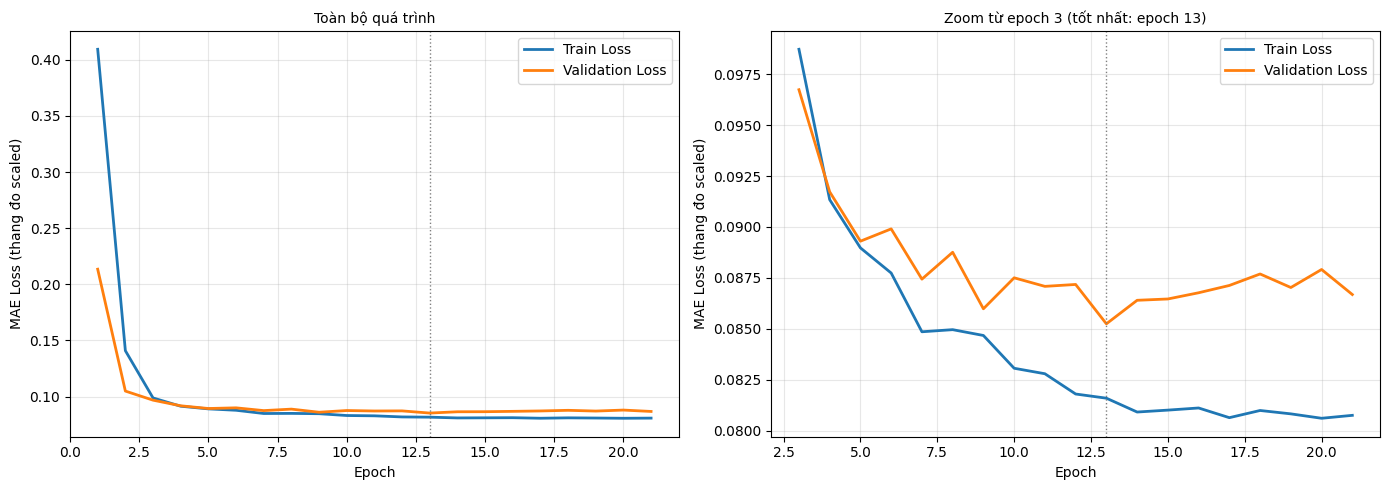

In [8]:
final_model, final_val_loss, history = train_model(
    train_scaled, X_val, y_val, pm25_col_idx,
    window_size=WINDOW_SIZE, horizon=HORIZON, hidden_size=BEST_HIDDEN, lr=BEST_LR,
    max_epochs=40, patience=8, device=device, verbose=True,
)
best_epoch = int(np.argmin(history['val_loss'])) + 1
print(f"\nBest val_loss (MAE thang đo scaled, trung bình trên {len(X_val)} fold validate) = {final_val_loss:.5f} (epoch {best_epoch})")

# 2 panel: (trái) toàn bộ quá trình, (phải) zoom từ epoch 3 - vì 2 epoch đầu giảm quá mạnh
# (0.41 -> 0.10) làm trục y bị kéo giãn, che mất diễn biến thật sự của các epoch còn lại
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_full = range(1, len(history['train_loss']) + 1)
axes[0].plot(epochs_full, history['train_loss'], label='Train Loss', linewidth=2)
axes[0].plot(epochs_full, history['val_loss'], label='Validation Loss', linewidth=2)
axes[0].axvline(best_epoch, color='gray', linestyle=':', linewidth=1)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('MAE Loss (thang đo scaled)')
axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[0].set_title('Toàn bộ quá trình', fontsize=10)

zoom_from = 3
epochs_zoom = range(zoom_from, len(history['train_loss']) + 1)
axes[1].plot(epochs_zoom, history['train_loss'][zoom_from - 1:], label='Train Loss', linewidth=2)
axes[1].plot(epochs_zoom, history['val_loss'][zoom_from - 1:], label='Validation Loss', linewidth=2)
axes[1].axvline(best_epoch, color='gray', linestyle=':', linewidth=1)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('MAE Loss (thang đo scaled)')
axes[1].legend(); axes[1].grid(True, alpha=0.3)
axes[1].set_title(f'Zoom từ epoch {zoom_from} (tốt nhất: epoch {best_epoch})', fontsize=10)

plt.tight_layout()
plt.show()

##### Walk-forward + Fine-tune Đánh giá trên Test (4 khối: 7, 7, 7, 7 ngày)

In [9]:
FT_LR = BEST_LR * 0.1
FT_EPOCHS = 5
print(f"Fine-tune: lr={FT_LR}, epochs={FT_EPOCHS}")

history_context = pool_scaled.tail(WINDOW_SIZE)  # lookback ban đầu = hết toàn bộ Pool (Train+Validate), ngày trước Test
extended_train = pool_scaled.copy()  # sẽ mở rộng dần bằng dữ liệu thật từng khối, xuất phát từ toàn bộ Pool

block_results = []
all_true, all_pred, all_times = [], [], []
start = 0

for i, block_size in enumerate(TEST_BLOCKS, start=1):
    block_target = test_scaled.iloc[start:start + block_size]

    final_model.eval()
    X = history_context.values[np.newaxis, :, :].astype(np.float32)
    with torch.no_grad():
        pred_scaled_full = final_model(torch.from_numpy(X).to(device)).cpu().numpy()[0]  # độ dài = HORIZON
    pred_scaled = pred_scaled_full[:block_size]  # chỉ lấy đúng block_size giá trị đầu (<= HORIZON)

    # GRU dự báo RESIDUAL (không phải PM2.5 tuyệt đối) -> cộng lại Trend để tái tạo PM2.5 dự báo
    pred_residual_block = inverse_transform_col(pred_scaled, pm25_col_idx, scaler, n_features)
    current_trend = trend_series.loc[block_target.index[0]]  # Trend tại ngày đầu khối, giữ phẳng cả khối
    pred_pm25_block = current_trend + pred_residual_block
    true_pm25_block = pm25_full_raw.loc[block_target.index].values  # PM2.5 THẬT (thang đo gốc, không qua Residual)
    mae, rmse = mae_rmse(true_pm25_block, pred_pm25_block)

    print(f"Khối {i} ({block_target.index.min().date()} -> {block_target.index.max().date()}, "
          f"{block_size} ngày): MAE = {mae:.4f} µg/m³, RMSE = {rmse:.4f} µg/m³")

    block_results.append({'Khối': i, 'Từ ngày': block_target.index.min().date(),
                           'Đến ngày': block_target.index.max().date(), 'Số ngày': block_size,
                           'MAE (µg/m³)': mae, 'RMSE (µg/m³)': rmse})
    all_true.append(true_pm25_block)
    all_pred.append(pred_pm25_block)
    all_times.append(block_target.index)

    # Cập nhật lookback: bỏ các ngày cũ nhất, thêm block THẬT vừa đánh giá, giữ đúng WINDOW_SIZE ngày gần nhất
    history_context = pd.concat([history_context, block_target]).tail(WINDOW_SIZE)
    extended_train = pd.concat([extended_train, block_target])
    start += block_size

    if i < len(TEST_BLOCKS):
        final_model, ft_losses = fine_tune(
            final_model, extended_train, pm25_col_idx, WINDOW_SIZE, HORIZON,
            lr=FT_LR, epochs=FT_EPOCHS, batch_size=64, device=device,
        )
        print(f"  -> Fine-tune {FT_EPOCHS} epoch với dữ liệu thật Khối {i}: "
              f"train_loss {ft_losses[0]:.5f} -> {ft_losses[-1]:.5f}")

true_pm25 = np.concatenate(all_true)
pred_pm25 = np.concatenate(all_pred)
target_times = pd.DatetimeIndex(np.concatenate(all_times))

mae_overall, rmse_overall = mae_rmse(true_pm25, pred_pm25)
print(f"\nTổng hợp toàn bộ {len(true_pm25)} ngày: MAE = {mae_overall:.4f} µg/m³, RMSE = {rmse_overall:.4f} µg/m³")

block_df = pd.DataFrame(block_results)
block_df

Fine-tune: lr=0.0001, epochs=5
Khối 1 (2026-07-27 -> 2026-08-02, 7 ngày): MAE = 2.7355 µg/m³, RMSE = 3.6242 µg/m³


  -> Fine-tune 5 epoch với dữ liệu thật Khối 1: train_loss 0.08185 -> 0.08144
Khối 2 (2026-08-03 -> 2026-08-09, 7 ngày): MAE = 4.2727 µg/m³, RMSE = 5.1055 µg/m³


  -> Fine-tune 5 epoch với dữ liệu thật Khối 2: train_loss 0.08166 -> 0.08103
Khối 3 (2026-08-10 -> 2026-08-16, 7 ngày): MAE = 1.8166 µg/m³, RMSE = 2.1836 µg/m³


  -> Fine-tune 5 epoch với dữ liệu thật Khối 3: train_loss 0.08076 -> 0.08107
Khối 4 (2026-08-17 -> 2026-08-23, 7 ngày): MAE = 2.3117 µg/m³, RMSE = 2.5557 µg/m³

Tổng hợp toàn bộ 28 ngày: MAE = 2.7841 µg/m³, RMSE = 3.5532 µg/m³


,Khối,Từ ngày,Đến ngày,Số ngày,MAE (µg/m³),RMSE (µg/m³)
0,1,2026-07-27,2026-08-02,7,2.735457,3.624178
1,2,2026-08-03,2026-08-09,7,4.272669,5.105537
2,3,2026-08-10,2026-08-16,7,1.816602,2.183596
3,4,2026-08-17,2026-08-23,7,2.311718,2.555669


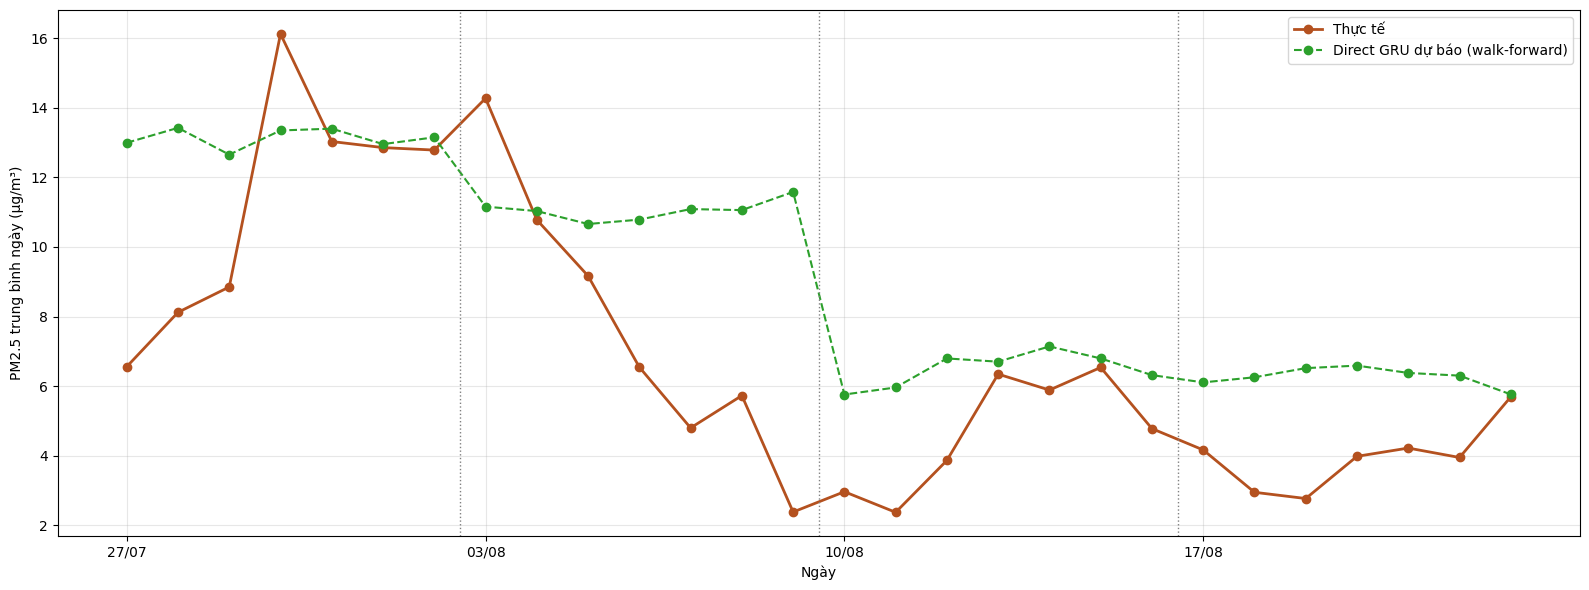

In [10]:
plt.figure(figsize=(16, 6))
plt.plot(target_times, true_pm25, label='Thực tế', color='#b4511f', linewidth=2, marker='o')
plt.plot(target_times, pred_pm25, label='Direct GRU dự báo (walk-forward)', color='#2ca02c',
         linestyle='--', linewidth=1.5, marker='o')

# Đánh dấu ranh giới giữa các khối
boundary = 0
for block_size in TEST_BLOCKS[:-1]:
    boundary += block_size
    plt.axvline(target_times[boundary - 1] + pd.Timedelta(hours=12), color='gray', linestyle=':', linewidth=1)

# Xtick đặt đúng tại mốc bắt đầu mỗi khối
tick_positions = []
start = 0
for block_size in TEST_BLOCKS:
    tick_positions.append(target_times[start])
    start += block_size
plt.xticks(tick_positions, [t.strftime('%d/%m') for t in tick_positions], rotation=0)

plt.xlabel('Ngày'); plt.ylabel('PM2.5 trung bình ngày (µg/m³)')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

##### Residual Diagnostics (toàn bộ 29 ngày)

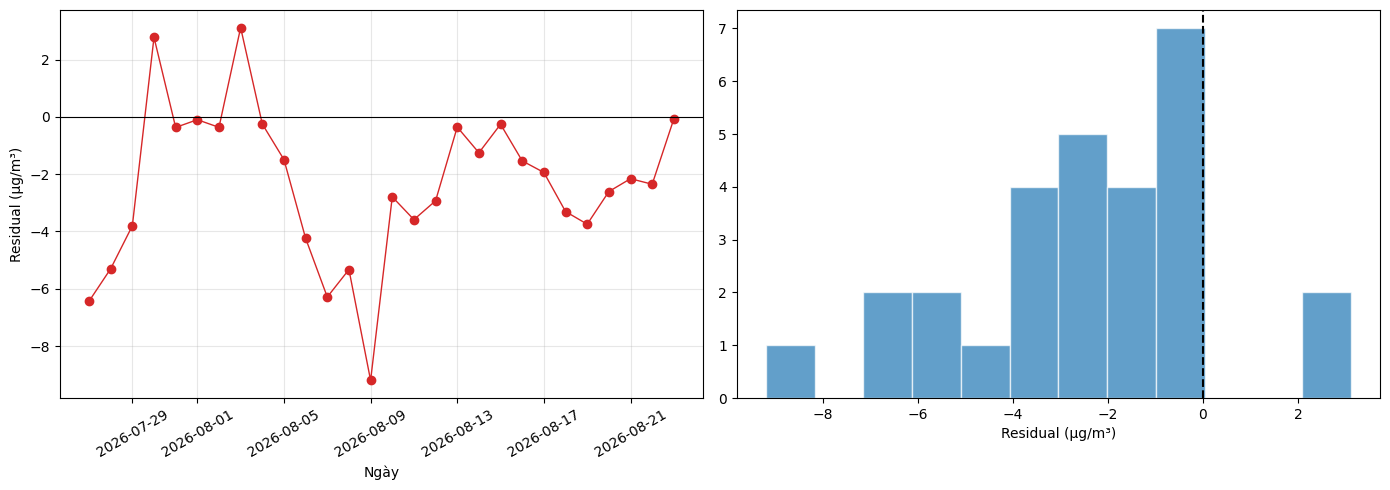

Residual mean: -2.364 µg/m³, std: 2.653 µg/m³


In [11]:
residuals = true_pm25 - pred_pm25

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(target_times, residuals, linewidth=1, color='#d62728', marker='o')
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_xlabel('Ngày'); axes[0].set_ylabel('Residual (µg/m³)')
axes[0].tick_params(axis='x', rotation=30)
axes[0].grid(True, alpha=0.3)

axes[1].hist(residuals, bins=12, color='#1f77b4', alpha=0.7, edgecolor='white')
axes[1].axvline(0, color='black', linestyle='--')
axes[1].set_xlabel('Residual (µg/m³)')

plt.tight_layout()
plt.show()
print(f"Residual mean: {residuals.mean():.3f} µg/m³, std: {residuals.std():.3f} µg/m³")

##### Lưu Model

In [12]:
import os

os.makedirs('data/processed', exist_ok=True)
torch.save({
    'model_state_dict': final_model.state_dict(),
    'window_size': WINDOW_SIZE,
    'horizon': HORIZON,
    'hidden_size': BEST_HIDDEN,
    'num_layers': 2,
    'dropout': 0.2,
    'lr': BEST_LR,
    'granularity': 'daily',
    'eval_scheme': 'decomposition_hybrid_walk_forward_finetune',
    'ewma_span': EWMA_SPAN,
}, 'data/processed/gru_hybrid_daily_h7_lb28_decomp.pt')
print("Đã lưu model vào data/processed/gru_hybrid_daily_h7_lb28_decomp.pt")

Đã lưu model vào data/processed/gru_hybrid_daily_h7_lb28_decomp.pt
